# CNN Training for Tomato Disease Classification

This notebook demonstrates how to train a CNN on the tomato disease dataset, splitting the data for train/validation, and evaluating performance. The validation folder will be reserved for final testing.

In [1]:
# 1. Imports and Setup
import sys
from pathlib import Path
project_root = Path.cwd().parent
if str(project_root) not in sys.path:
    sys.path.insert(0, str(project_root))

import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import tensorflow as tf
from tensorflow.keras.callbacks import EarlyStopping
from tensorflow.keras.utils import to_categorical
from sklearn.model_selection import train_test_split
from PIL import Image
from config import TRAIN_DIR, BATCH_SIZE, IMAGE_SIZE, N_CLASSES, EPOCHS, VAL_DIR, CLASS_NAMES
from src.preprocess import train_transform, resize_and_rescale
from src.visualization import plot_history, plot_confusion_matrix
from src.evaluate import compute_confusion_matrix, print_classification_report
from models.cnn import build_cnn


## 2. Load and Prepare Data

We will load all images and labels from the train folder, split into train/val, and preprocess them for the CNN.

In [2]:
# Gather all image paths and labels
image_paths, labels = [], []
class_dirs = sorted([d for d in Path(TRAIN_DIR).iterdir() if d.is_dir()])
class_to_idx = {d.name: i for i, d in enumerate(class_dirs)}

for d in class_dirs:
    for p in d.glob('*'):
        image_paths.append(str(p))
        labels.append(class_to_idx[d.name])

# Split into train/val
X_train, X_val, y_train, y_val = train_test_split(
    image_paths, labels, test_size=0.2, stratify=labels, random_state=42)

print(f"Train: {len(X_train)} images, Val: {len(X_val)} images, Classes: {len(class_to_idx)}")

Train: 8000 images, Val: 2000 images, Classes: 10


In [3]:
# Use the existing resize_and_rescale from src.preprocess
from src.preprocess import resize_and_rescale

def load_and_preprocess(paths):
    imgs = []
    for p in paths:
        img = Image.open(p).convert('RGB')
        img = np.asarray(img)
        img = resize_and_rescale(img[np.newaxis, ...]).numpy()[0]  # Add batch dim for keras layer
        imgs.append(img)
    return np.stack(imgs)

X_train_arr = load_and_preprocess(X_train)
X_val_arr = load_and_preprocess(X_val)
y_train_arr = to_categorical(y_train, num_classes=len(class_to_idx))
y_val_arr = to_categorical(y_val, num_classes=len(class_to_idx))

print('Train images shape:', X_train_arr.shape)
print('Val images shape:', X_val_arr.shape)

Train images shape: (8000, 256, 256, 3)
Val images shape: (2000, 256, 256, 3)


## 3. Build and Train the CNN

We will now build the CNN and train it on the training set, validating on the split validation set.

In [4]:
# Build the CNN model
input_shape = (IMAGE_SIZE, IMAGE_SIZE, 3)
n_classes = len(class_to_idx)
model = build_cnn(input_shape, n_classes)
model.compile(optimizer='adam', loss='categorical_crossentropy', metrics=['accuracy'])
model.summary()

/Users/ndeyeawasalane/Downloads/tomato-disease-classification/.venv/lib/python3.13/site-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 254, 254, 32)   │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 127, 127, 32)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 125, 125, 64)   │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 62, 62, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 60, 60, 64)     │        36,928 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 30, 30, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_3 (Conv2D)               │ (None, 28, 28, 64)     │        36,928 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_3 (MaxPooling2D)  │ (None, 14, 14, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_4 (Conv2D)               │ (None, 12, 12, 64)     │        36,928 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_4 (MaxPooling2D)  │ (None, 6, 6, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_5 (Conv2D)               │ (None, 4, 4, 64)       │        36,928 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_5 (MaxPooling2D)  │ (None, 2, 2, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 64)             │        16,448 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 10)             │           650 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 184,202 (719.54 KB)

 Trainable params: 184,202 (719.54 KB)

 Non-trainable params: 0 (0.00 B)

In [5]:
early_stopping = EarlyStopping(monitor='val_loss', patience=4, restore_best_weights=True)
history = model.fit(
    X_train_arr, y_train_arr,
    validation_data=(X_val_arr, y_val_arr),
    epochs=EPOCHS,
    batch_size=BATCH_SIZE,
    callbacks=[early_stopping]
)

Epoch 1/31
250/250 ━━━━━━━━━━━━━━━━━━━━ 57s 225ms/step - accuracy: 0.3331 - loss: 1.7849 - val_accuracy: 0.5190 - val_loss: 1.3340
Epoch 2/31
250/250 ━━━━━━━━━━━━━━━━━━━━ 54s 216ms/step - accuracy: 0.5832 - loss: 1.1468 - val_accuracy: 0.6565 - val_loss: 0.9311
Epoch 3/31
250/250 ━━━━━━━━━━━━━━━━━━━━ 53s 213ms/step - accuracy: 0.7169 - loss: 0.7939 - val_accuracy: 0.7815 - val_loss: 0.6363
Epoch 4/31
250/250 ━━━━━━━━━━━━━━━━━━━━ 53s 211ms/step - accuracy: 0.7755 - loss: 0.6370 - val_accuracy: 0.7765 - val_loss: 0.6508
Epoch 5/31
250/250 ━━━━━━━━━━━━━━━━━━━━ 53s 210ms/step - accuracy: 0.8170 - loss: 0.5039 - val_accuracy: 0.7645 - val_loss: 0.6419
Epoch 6/31
250/250 ━━━━━━━━━━━━━━━━━━━━ 53s 210ms/step - accuracy: 0.8495 - loss: 0.4288 - val_accuracy: 0.7685 - val_loss: 0.6572
Epoch 7/31
250/250 ━━━━━━━━━━━━━━━━━━━━ 53s 213ms/step - accuracy: 0.8636 - loss: 0.3877 - val_accuracy: 0.8350 - val_loss: 0.4580
Epoch 8/31
250/250 ━━━━━━━━━━━━━━━━━━━━ 53s 214ms/step - accuracy: 0.8900 - loss: 0

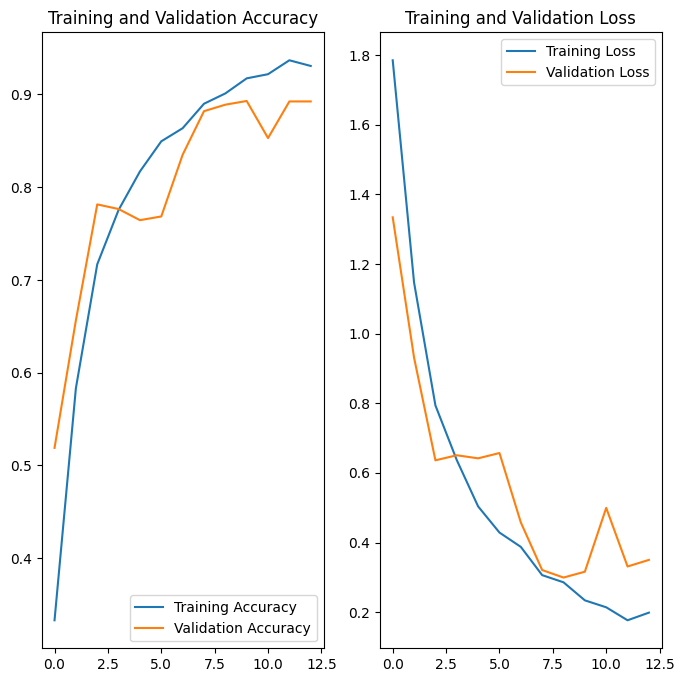

In [6]:
# Plot training history
plot_history(history)

## 4. Next Steps

- Evaluate on the reserved validation folder as a test set after tuning.
- Try other models or feature engineering approaches as needed.
- Save the trained model for later use.

## 5. Evaluate on the Validation Folder (Test Set)

Now we will load the images from the `val` folder, preprocess them, and evaluate the trained CNN on this true test set.

In [7]:
# Load test set from val folder
test_dir = Path(VAL_DIR)
test_image_paths, test_labels = [], []
test_class_dirs = sorted([d for d in test_dir.iterdir() if d.is_dir()])
test_class_to_idx = {d.name: i for i, d in enumerate(test_class_dirs)}

for d in test_class_dirs:
    for p in d.glob('*'):
        test_image_paths.append(str(p))
        test_labels.append(test_class_to_idx[d.name])

# Preprocess test images
X_test_arr = load_and_preprocess(test_image_paths)
y_test_arr = to_categorical(test_labels, num_classes=len(class_to_idx))

print('Test images shape:', X_test_arr.shape)


Test images shape: (1000, 256, 256, 3)


In [8]:
# Evaluate on test set
test_loss, test_acc = model.evaluate(X_test_arr, y_test_arr, batch_size=BATCH_SIZE)
print(f"Test set accuracy: {test_acc:.4f}")

32/32 ━━━━━━━━━━━━━━━━━━━━ 2s 47ms/step - accuracy: 0.8680 - loss: 0.4170
Test set accuracy: 0.8680


In [9]:
y_pred_probs = model.predict(X_test_arr)
y_pred = np.argmax(y_pred_probs, axis=1)
y_true = np.argmax(y_test_arr, axis=1)

32/32 ━━━━━━━━━━━━━━━━━━━━ 2s 48ms/step


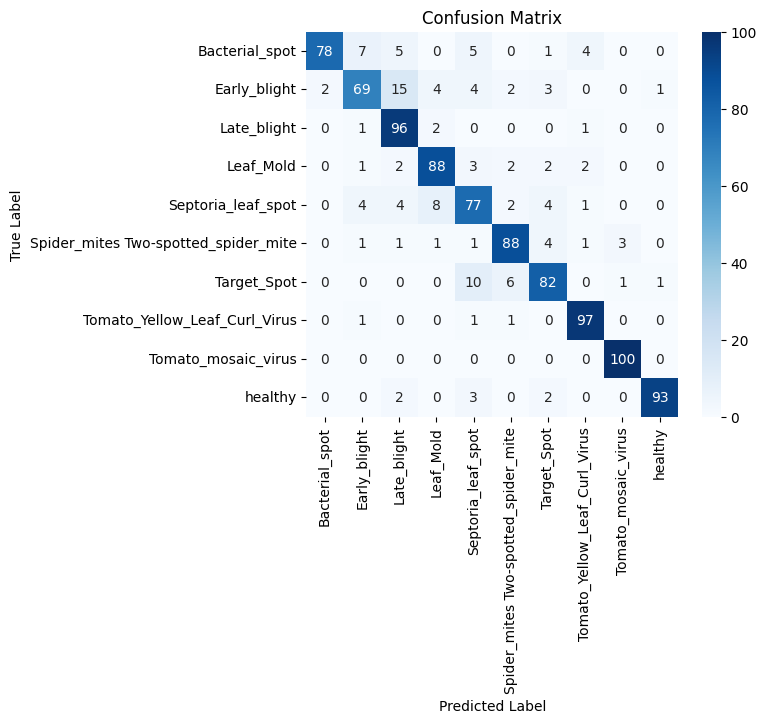

In [10]:
cm = compute_confusion_matrix(y_true, y_pred)

plot_confusion_matrix(cm, class_names=[i.split("___")[-1] for i in CLASS_NAMES])

In [11]:
print_classification_report(y_true, y_pred, target_names=[i.split("___")[-1] for i in CLASS_NAMES])

                                      precision    recall  f1-score   support

                      Bacterial_spot       0.97      0.78      0.87       100
                        Early_blight       0.82      0.69      0.75       100
                         Late_blight       0.77      0.96      0.85       100
                           Leaf_Mold       0.85      0.88      0.87       100
                  Septoria_leaf_spot       0.74      0.77      0.75       100
Spider_mites Two-spotted_spider_mite       0.87      0.88      0.88       100
                         Target_Spot       0.84      0.82      0.83       100
       Tomato_Yellow_Leaf_Curl_Virus       0.92      0.97      0.94       100
                 Tomato_mosaic_virus       0.96      1.00      0.98       100
                             healthy       0.98      0.93      0.95       100

                            accuracy                           0.87      1000
                           macro avg       0.87      0.87     

In [12]:
# # Save the trained model
# model.save('../models/cnn_tomato_disease_model.h5')
# print('Model saved as cnn_tomato_disease_model.h5')